# 01 — Preprocessing
## Smart City Surveillance System — CS 406 Digital Image Processing CCP

This notebook: downloads the Face Mask Dataset from Kaggle, samples & resizes images, generates noisy/degraded test pairs, and saves everything to Google Drive so later notebooks (spatial filtering, frequency filtering, segmentation, compression, recognition) can just load from Drive without redoing this step.

## Step 1 — Install Kaggle CLI

In [ ]:
!pip install kaggle -q

## Step 2 — Connect Kaggle credentials
Paste your **rotated** Kaggle API token below (Kaggle → Settings → API Tokens → Generate New Token). Never reuse a token that has been shared anywhere publicly.

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('YOUR_NEW_KAGGLE_TOKEN_HERE')

os.chmod('/root/.kaggle/access_token', 0o600)

In [ ]:
!kaggle competitions list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


## Step 3 — Mount Google Drive
This is where all processed data, figures, and tables will be saved so they survive Colab session disconnects and are available to every later notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/noisy', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results/figures', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results/tables', exist_ok=True)
print('Project dir ready at:', PROJECT_DIR)

Mounted at /content/drive
Project dir ready at: /content/drive/MyDrive/smart-city-surveillance-dip


## Step 4 — Download the Face Mask Dataset
Downloaded into Colab's local disk (`/content/`), not Drive — much faster to unzip 2.33GB locally, then we only save the small sampled/processed versions to Drive.

In [ ]:
!kaggle datasets download -d shiekhburhan/face-mask-dataset
!unzip -q face-mask-dataset.zip -d face_mask_dataset
!rm face-mask-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/shiekhburhan/face-mask-dataset
License(s): CC0-1.0
100% 2.33G/2.33G [00:19<00:00, 128MB/s]



## Step 5 — Inspect dataset structure

In [ ]:
from pathlib import Path

RAW_DIR = Path('face_mask_dataset/FMD_DATASET')
classes_check = ['with_mask', 'without_mask', 'incorrect_mask']

for c in classes_check:
    class_dir = RAW_DIR / c
    subfolders = [d.name for d in class_dir.iterdir() if d.is_dir()]
    total = sum(len(list((class_dir / sub).glob('*.jpg'))) for sub in subfolders)
    print(f'{c}: subfolders={subfolders}, total images={total}')

with_mask: subfolders=['complex', 'simple'], total images=4789
without_mask: subfolders=['complex', 'simple'], total images=4747
incorrect_mask: subfolders=['mc', 'mmc'], total images=5000


## Step 6 — Sample & resize images into `data/processed/`
We take a random subset of 300 images per class (900 total) — enough for robust filtering/segmentation/compression experiments without the runtime cost of the full 14,536 images. The full dataset is only needed later if you do the optional YOLO fine-tuning task.

In [ ]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

PROCESSED_DIR = Path('data/processed')   # local Colab disk for speed during this session
NOISY_DIR = Path('data/noisy')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NOISY_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (256, 256)
SAMPLE_PER_CLASS = 300

classes = {
    "with_mask": RAW_DIR / "with_mask",
    "without_mask": RAW_DIR / "without_mask",
    "incorrect_mask": RAW_DIR / "incorrect_mask",
}

def collect_images(class_dir):
    paths = []
    for sub in class_dir.iterdir():
        if sub.is_dir():
            paths.extend(list(sub.glob("*.jpg")))
    return paths

class_paths = {name: collect_images(path) for name, path in classes.items()}
for name, paths in class_paths.items():
    print(f"{name}: {len(paths)} images found")

random.seed(42)  # reproducibility for the report's methodology section
for class_name, paths in class_paths.items():
    sample = random.sample(paths, min(SAMPLE_PER_CLASS, len(paths)))
    out_dir = PROCESSED_DIR / class_name
    out_dir.mkdir(parents=True, exist_ok=True)
    for i, p in enumerate(sample):
        img = cv2.imread(str(p))
        if img is None:
            continue
        img_resized = cv2.resize(img, IMG_SIZE)
        cv2.imwrite(str(out_dir / f"{class_name}_{i:04d}.jpg"), img_resized)
    print(f"Processed {len(sample)} images for {class_name}")

with_mask: 4789 images found
without_mask: 4747 images found
incorrect_mask: 5000 images found
Processed 300 images for with_mask
Processed 300 images for without_mask
Processed 300 images for incorrect_mask


## Step 7 — Visual sanity check

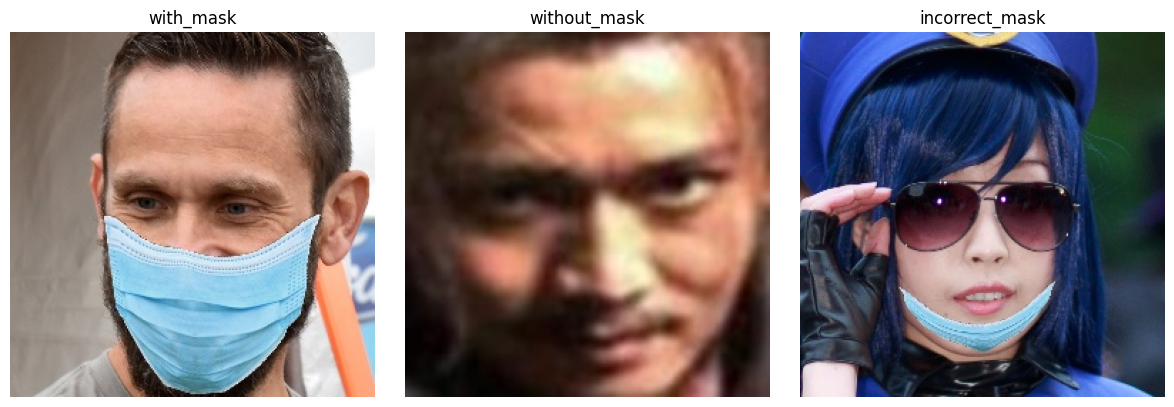

Saved sample_classes.png to Drive.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, class_name in zip(axes, classes.keys()):
    sample_file = list((PROCESSED_DIR / class_name).glob("*.jpg"))[0]
    img = cv2.cvtColor(cv2.imread(str(sample_file)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/sample_classes.png', dpi=150)
plt.show()
print('Saved sample_classes.png to Drive.')

## Step 8 — Generate noisy/degraded pairs
For every clean image, create 3 degraded versions: Gaussian noise, salt-and-pepper noise, and motion blur. These give controlled before/after pairs for PSNR/SSIM comparisons in Phase 3.

In [ ]:
def add_gaussian_noise(img, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img, amount=0.02):
    noisy = img.copy()
    num_salt = int(amount * img.size * 0.5)
    num_pepper = int(amount * img.size * 0.5)
    coords = [np.random.randint(0, i, num_salt) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, i, num_pepper) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 0
    return noisy

def add_motion_blur(img, size=15):
    kernel = np.zeros((size, size))
    kernel[int((size - 1) / 2), :] = np.ones(size)
    kernel /= size
    return cv2.filter2D(img, -1, kernel)

for class_name in classes.keys():
    src_dir = PROCESSED_DIR / class_name
    out_dir = NOISY_DIR / class_name
    out_dir.mkdir(parents=True, exist_ok=True)
    for img_path in src_dir.glob("*.jpg"):
        img = cv2.imread(str(img_path))
        stem = img_path.stem
        cv2.imwrite(str(out_dir / f"{stem}_gaussian.jpg"), add_gaussian_noise(img))
        cv2.imwrite(str(out_dir / f"{stem}_saltpepper.jpg"), add_salt_pepper_noise(img))
        cv2.imwrite(str(out_dir / f"{stem}_blur.jpg"), add_motion_blur(img))
    print(f"Generated noisy variants for {class_name}")

Generated noisy variants for with_mask
Generated noisy variants for without_mask
Generated noisy variants for incorrect_mask


In [ ]:
import os
for class_name in ["with_mask", "without_mask", "incorrect_mask"]:
    count = len(os.listdir(f"data/noisy/{class_name}"))
    print(f"{class_name}: {count} noisy images")

with_mask: 900 noisy images
without_mask: 900 noisy images
incorrect_mask: 900 noisy images


## Step 9 — Copy processed + noisy datasets to Google Drive
This is the key step: it persists your 900 clean + 2,700 noisy images to Drive so `02_spatial_filtering.ipynb` and every later notebook can load them directly, without needing to redownload or reprocess anything.

In [ ]:
!cp -r data/processed/* "$PROJECT_DIR/data/processed/"
!cp -r data/noisy/* "$PROJECT_DIR/data/noisy/"
print('Copied processed + noisy datasets to Google Drive.')

Copied processed + noisy datasets to Google Drive.


## Step 10 — Verify the Drive copy

In [ ]:
import os
for class_name in ["with_mask", "without_mask", "incorrect_mask"]:
    proc_count = len(os.listdir(f'{PROJECT_DIR}/data/processed/{class_name}'))
    noisy_count = len(os.listdir(f'{PROJECT_DIR}/data/noisy/{class_name}'))
    print(f"{class_name}: {proc_count} processed, {noisy_count} noisy (in Drive)")

with_mask: 300 processed, 900 noisy (in Drive)
without_mask: 300 processed, 900 noisy (in Drive)
incorrect_mask: 300 processed, 900 noisy (in Drive)


---
**Preprocessing complete.** All data now lives in your Google Drive at:
`MyDrive/smart-city-surveillance-dip/data/processed/` and `.../data/noisy/`

**Next: `02_spatial_filtering.ipynb`** will mount Drive, load this data directly (no redownload needed), and implement Mean/Median/Laplacian filtering with PSNR/SSIM evaluation.